In [7]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
# Carregar o arquivo .mat
data = scipy.io.loadmat('/Users/alanasarahfreitasdarocha/Documents/UFPR 8 periodo/Atividade 2 - TCC/IN_OUT_PA.mat')

# Exibir os cabeçalhos
print(data.keys())
u = data['in'].flatten()  # Entrada, flatten é usado para transformar em uma unica dimensão 
y = data['out'].flatten()  # Saída

print(u[:5]) # printando 5 primeiros valores
print(y[:5])


dict_keys(['__header__', '__version__', '__globals__', 'in', 'out'])
[0.62302363 0.60603586 0.62319308 0.66196767 0.69947785]
[0.49243503 0.47870008 0.47848198 0.48890297 0.50141688]


In [8]:
# Definir a ordem do polinômio (P) e o número de atrasos (M)
P = 2  # Ordem do polinômio
M = 2  # Memória 

# Número de dados
N = len(u) #99
print(N)
# Inicializar a matriz de regressão XX
XX = []

# Construir a matriz de regressão XX utilizando loop
for n in range(M, N):  # Evitar os primeiros M valores, pois nao teremos memoria    
    linha = []
    for m in range(M):  # Para memória
        for p in range(1, P + 1):  # Para cada potência
            linha.append(u[n - m] ** p)
    XX.append(linha)

# Converter a lista para um array NumPy
XX = np.array(XX)

# Ajustar o vetor de saída correspondente
y_adjusted = y[M:]

# Ver as primeiras linhas da matriz XX e do vetor Y
print("Primeiras linhas de XX:", XX[:5])
print("Primeiras linhas de Y:", y_adjusted[:5])

99
Primeiras linhas de XX: [[0.62319308 0.38836962 0.60603586 0.36727947]
 [0.66196767 0.4382012  0.62319308 0.38836962]
 [0.69947785 0.48926926 0.66196767 0.4382012 ]
 [0.72012176 0.51857534 0.69947785 0.48926926]
 [0.71870468 0.51653642 0.72012176 0.51857534]]
Primeiras linhas de Y: [0.47848198 0.48890297 0.50141688 0.51037182 0.5128654 ]


Coeficientes estimados: [ 1.03625919 -0.63794799 -0.04639047  0.2382853 ]


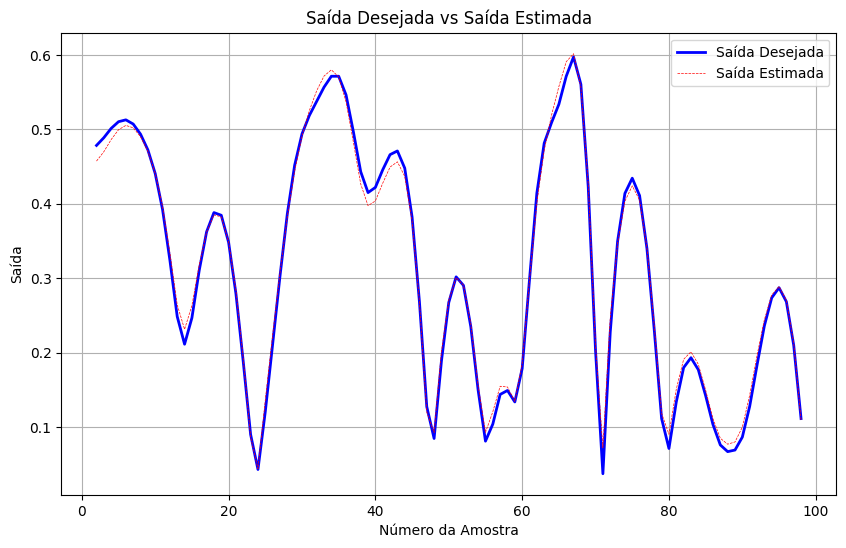

In [11]:
# Resolver o problema de mínimos quadrados
coeffs = np.linalg.lstsq(XX, y_adjusted, rcond=None)[0] 
y_estimated = XX @ coeffs
# Exibir os coeficientes estimados
print("Coeficientes estimados:", coeffs)

plt.figure(figsize=(10, 6))
plt.plot(range(M, N), y_adjusted, label='Saída Desejada', color='b', linewidth=2)
plt.plot(range(M, N), y_estimated, label='Saída Estimada', color='r', linestyle='--', linewidth=0.5)

# Configurar o gráfico
plt.title('Saída Desejada vs Saída Estimada')
plt.xlabel('Número da Amostra')
plt.ylabel('Saída')
plt.legend()
plt.grid(True)

# Mostrar o gráfico
plt.show()
